<a href="https://colab.research.google.com/github/sonakshi-vlsi/Limited-Data-Benchmark-Adaptation-for-Lithography-Hotspot-Detection/blob/main/hotspot_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== 1. Mount Drive =====
from google.colab import drive
drive.mount('/content/drive')

# ===== 2. Reload processed data =====
import numpy as np
loaded = np.load("/content/drive/MyDrive/iccad12_processed.npz")

def get_split(bm, split):
    return loaded[f"{bm}_X_{split}"], loaded[f"{bm}_y_{split}"]

# ===== 3. Rebuild CNN architecture =====
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_baseline_cnn(input_shape=(64, 64, 1)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(12, (3,3), activation="elu", padding="same")(inputs)
    x = layers.Conv2D(12, (3,3), activation="elu", padding="same")(x)
    x = layers.Conv2D(12, (3,3), activation=None, padding="same")(x)
    x = layers.BatchNormalization(momentum=0.99, epsilon=0.001)(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(12, (3,3), activation="elu", padding="same")(x)
    x = layers.Conv2D(12, (3,3), activation="elu", padding="same")(x)
    x = layers.Conv2D(12, (3,3), activation=None, padding="same")(x)
    x = layers.BatchNormalization(momentum=0.99, epsilon=0.001)(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling2D((5,5), padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs, name="baseline_cnn")

# ===== 4. Rebuild budget subsets =====
def make_budget_subset(X, y, fraction, seed):
    rng = np.random.RandomState(seed)
    hs_idx = np.where(y == 1)[0]
    nhs_idx = np.where(y == 0)[0]
    n_hs = int(round(len(hs_idx) * fraction))
    n_nhs = int(round(len(nhs_idx) * fraction))
    hs_sample = rng.choice(hs_idx, size=n_hs, replace=False)
    nhs_sample = rng.choice(nhs_idx, size=n_nhs, replace=False)
    idx = np.concatenate([hs_sample, nhs_sample])
    rng.shuffle(idx)
    return X[idx], y[idx]

TARGET_BENCHMARKS = ["iccad1", "iccad2", "iccad4", "iccad5"]
BUDGETS = [0.05, 0.10, 0.20]
SEEDS = [0, 1, 2]

budget_data = {}
for bm in TARGET_BENCHMARKS:
    X_full, y_full = get_split(bm, "train")
    for frac in BUDGETS:
        for seed in SEEDS:
            key = f"{bm}_{int(frac*100)}pct_seed{seed}"
            budget_data[key] = make_budget_subset(X_full, y_full, frac, seed)

# ===== 5. Metrics + incremental saving =====
import gc, os
import pandas as pd
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, precision_score, recall_score, f1_score

FULL_RESULTS_PATH = "/content/drive/MyDrive/full_metrics_results.csv"

# start fresh for this complete-metrics run
if os.path.exists(FULL_RESULTS_PATH):
    os.remove(FULL_RESULTS_PATH)

def append_full_result(row):
    df_row = pd.DataFrame([row])
    header = not os.path.exists(FULL_RESULTS_PATH)
    df_row.to_csv(FULL_RESULTS_PATH, mode="a", header=header, index=False)

def get_model(pretrained=False, freeze_conv=False):
    m = build_baseline_cnn()
    if pretrained:
        m.load_weights("/content/drive/MyDrive/source_model_iccad3.weights.h5")
    if freeze_conv:
        for layer in m.layers:
            if "conv2d" in layer.name.lower():
                layer.trainable = False
    return m

def train_and_eval_full(X_train, y_train, X_test, y_test, pretrained, freeze_conv, lr, epochs=15):
    model = get_model(pretrained=pretrained, freeze_conv=freeze_conv)
    model.compile(optimizer=keras.optimizers.Nadam(learning_rate=lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
    n = len(X_train)
    bs = min(8, n)
    eff_epochs = max(epochs, 50 if n < 10 else epochs)
    model.fit(X_train, y_train, epochs=eff_epochs, batch_size=bs, verbose=0)

    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    result = {
        "balanced_acc": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    del model
    keras.backend.clear_session()
    gc.collect()
    return result

# ===== 6. Zero-shot for all 4 benchmarks (no training needed) =====
for bm in TARGET_BENCHMARKS:
    X_test, y_test = get_split(bm, "test")
    model = get_model(pretrained=True)
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    result = {
        "balanced_acc": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    del model
    keras.backend.clear_session()
    gc.collect()
    append_full_result({"benchmark": bm, "budget_pct": "NA", "seed": "NA", "method": "zero_shot", "n_hs_train": 0, **result})
    print(f"{bm} zero_shot: BA={result['balanced_acc']:.3f}")

# ===== 7. Main sweep: scratch, head_only, adapted — full metrics =====
for bm in TARGET_BENCHMARKS:
    X_test, y_test = get_split(bm, "test")
    for frac in BUDGETS:
        for seed in SEEDS:
            key = f"{bm}_{int(frac*100)}pct_seed{seed}"
            X_sub, y_sub = budget_data[key]
            n_hs = int(y_sub.sum())

            r_scratch = train_and_eval_full(X_sub, y_sub, X_test, y_test, pretrained=False, freeze_conv=False, lr=1e-3)
            append_full_result({"benchmark": bm, "budget_pct": int(frac*100), "seed": seed, "method": "scratch", "n_hs_train": n_hs, **r_scratch})

            r_head = train_and_eval_full(X_sub, y_sub, X_test, y_test, pretrained=True, freeze_conv=True, lr=1e-3)
            append_full_result({"benchmark": bm, "budget_pct": int(frac*100), "seed": seed, "method": "head_only", "n_hs_train": n_hs, **r_head})

            r_adapted = train_and_eval_full(X_sub, y_sub, X_test, y_test, pretrained=True, freeze_conv=False, lr=1e-4)
            append_full_result({"benchmark": bm, "budget_pct": int(frac*100), "seed": seed, "method": "adapted", "n_hs_train": n_hs, **r_adapted})

            print(f"{key}: scratch BA={r_scratch['balanced_acc']:.3f} | head_only BA={r_head['balanced_acc']:.3f} | adapted BA={r_adapted['balanced_acc']:.3f}")

print("\nAll done — saved to", FULL_RESULTS_PATH)

KeyboardInterrupt: 

In [ ]:
# ===== 1. Mount Drive =====
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


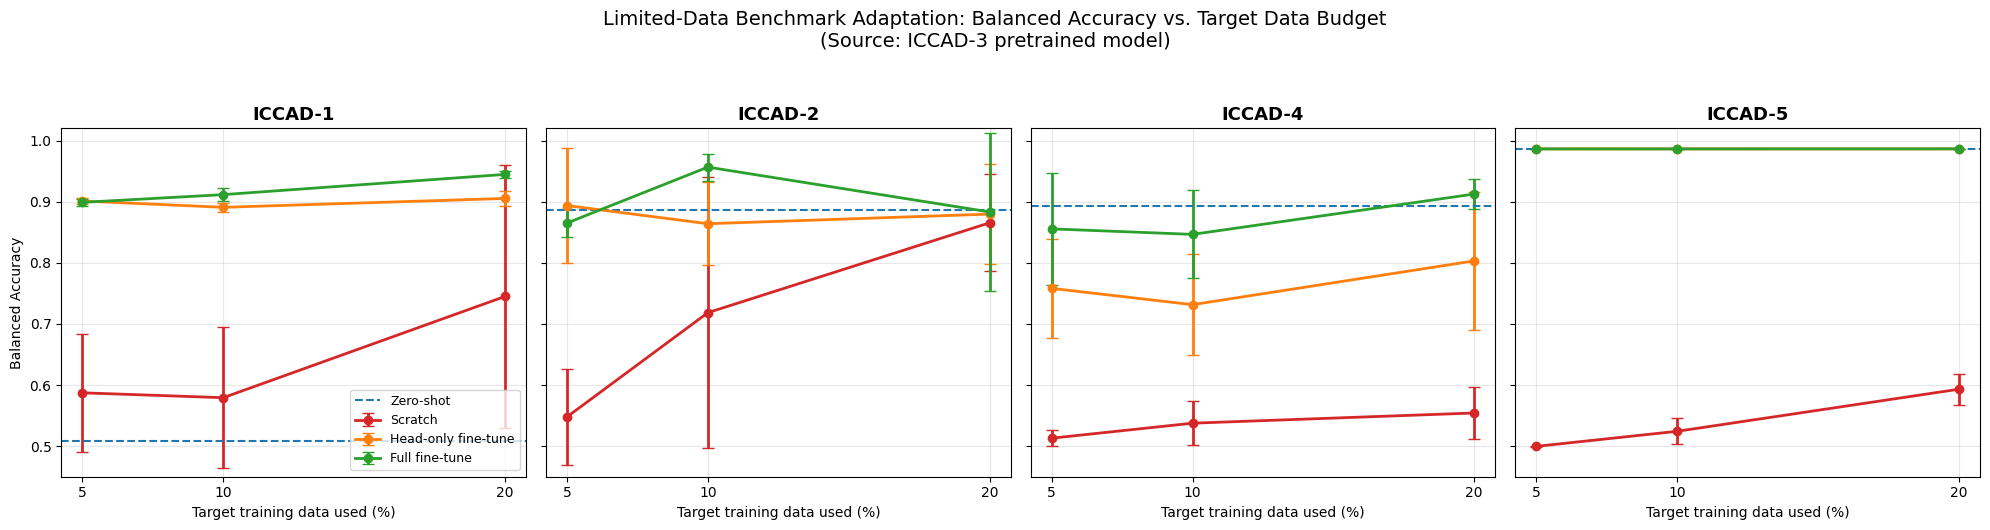

Saved to Drive: adaptation_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your full metrics results
df = pd.read_csv("/content/drive/MyDrive/full_metrics_results.csv")
df["budget_pct"] = pd.to_numeric(df["budget_pct"], errors="coerce")

benchmarks = ["iccad1", "iccad2", "iccad4", "iccad5"]
methods = ["scratch", "head_only", "adapted"]
colors = {"scratch": "#d62728", "head_only": "#ff7f0e", "adapted": "#2ca02c", "zero_shot": "#1f77b4"}
labels = {"scratch": "Scratch", "head_only": "Head-only fine-tune", "adapted": "Full fine-tune", "zero_shot": "Zero-shot"}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, bm in zip(axes, benchmarks):
    sub = df[(df["benchmark"] == bm) & (df["method"] != "zero_shot")]
    agg = sub.groupby(["method", "budget_pct"])["balanced_acc"].agg(["mean", "std"]).reset_index()

    for method in methods:
        m = agg[agg["method"] == method].sort_values("budget_pct")
        ax.errorbar(m["budget_pct"], m["mean"], yerr=m["std"], marker="o",
                    label=labels[method], color=colors[method], capsize=4, linewidth=2)

    zs = df[(df["benchmark"] == bm) & (df["method"] == "zero_shot")]["balanced_acc"].values
    if len(zs):
        ax.axhline(zs[0], color=colors["zero_shot"], linestyle="--", linewidth=1.5, label=labels["zero_shot"])

    ax.set_title(bm.upper().replace("ICCAD", "ICCAD-"), fontsize=13, fontweight="bold")
    ax.set_xlabel("Target training data used (%)")
    ax.set_xticks([5, 10, 20])
    ax.set_ylim(0.45, 1.02)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Balanced Accuracy")
axes[0].legend(loc="lower right", fontsize=9)
plt.suptitle("Limited-Data Benchmark Adaptation: Balanced Accuracy vs. Target Data Budget\n(Source: ICCAD-3 pretrained model)", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/adaptation_curves.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved to Drive: adaptation_curves.png")

In [ ]:
import numpy as np
loaded = np.load("/content/drive/MyDrive/iccad12_processed.npz")

def get_split(bm, split):
    return loaded[f"{bm}_X_{split}"], loaded[f"{bm}_y_{split}"]

# ===== 3. Rebuild CNN architecture =====
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_baseline_cnn(input_shape=(64, 64, 1)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(12, (3,3), activation="elu", padding="same")(inputs)
    x = layers.Conv2D(12, (3,3), activation="elu", padding="same")(x)
    x = layers.Conv2D(12, (3,3), activation=None, padding="same")(x)
    x = layers.BatchNormalization(momentum=0.99, epsilon=0.001)(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(12, (3,3), activation="elu", padding="same")(x)
    x = layers.Conv2D(12, (3,3), activation="elu", padding="same")(x)
    x = layers.Conv2D(12, (3,3), activation=None, padding="same")(x)
    x = layers.BatchNormalization(momentum=0.99, epsilon=0.001)(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling2D((5,5), padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs, name="baseline_cnn")

# ===== 4. Rebuild budget subsets =====
def make_budget_subset(X, y, fraction, seed):
    rng = np.random.RandomState(seed)
    hs_idx = np.where(y == 1)[0]
    nhs_idx = np.where(y == 0)[0]
    n_hs = int(round(len(hs_idx) * fraction))
    n_nhs = int(round(len(nhs_idx) * fraction))
    hs_sample = rng.choice(hs_idx, size=n_hs, replace=False)
    nhs_sample = rng.choice(nhs_idx, size=n_nhs, replace=False)
    idx = np.concatenate([hs_sample, nhs_sample])
    rng.shuffle(idx)
    return X[idx], y[idx]

TARGET_BENCHMARKS = ["iccad1", "iccad2", "iccad4", "iccad5"]
BUDGETS = [0.05, 0.10, 0.20]
SEEDS = [0, 1, 2]

budget_data = {}
for bm in TARGET_BENCHMARKS:
    X_full, y_full = get_split(bm, "train")
    for frac in BUDGETS:
        for seed in SEEDS:
            key = f"{bm}_{int(frac*100)}pct_seed{seed}"
            budget_data[key] = make_budget_subset(X_full, y_full, frac, seed)

# ===== 5. Metrics + incremental saving =====
import gc, os
import pandas as pd
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, precision_score, recall_score, f1_score

FULL_RESULTS_PATH = "/content/drive/MyDrive/full_metrics_results.csv"

# start fresh for this complete-metrics run
if os.path.exists(FULL_RESULTS_PATH):
    os.remove(FULL_RESULTS_PATH)

def append_full_result(row):
    df_row = pd.DataFrame([row])
    header = not os.path.exists(FULL_RESULTS_PATH)
    df_row.to_csv(FULL_RESULTS_PATH, mode="a", header=header, index=False)

def get_model(pretrained=False, freeze_conv=False):
    m = build_baseline_cnn()
    if pretrained:
        m.load_weights("/content/drive/MyDrive/source_model_iccad3.weights.h5")
    if freeze_conv:
        for layer in m.layers:
            if "conv2d" in layer.name.lower():
                layer.trainable = False
    return m

def train_and_eval_full(X_train, y_train, X_test, y_test, pretrained, freeze_conv, lr, epochs=15):
    model = get_model(pretrained=pretrained, freeze_conv=freeze_conv)
    model.compile(optimizer=keras.optimizers.Nadam(learning_rate=lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
    n = len(X_train)
    bs = min(8, n)
    eff_epochs = max(epochs, 50 if n < 10 else epochs)
    model.fit(X_train, y_train, epochs=eff_epochs, batch_size=bs, verbose=0)

    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    result = {
        "balanced_acc": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    del model
    keras.backend.clear_session()
    gc.collect()
    return result

iccad1 done
iccad2 done
iccad4 done
iccad5 done


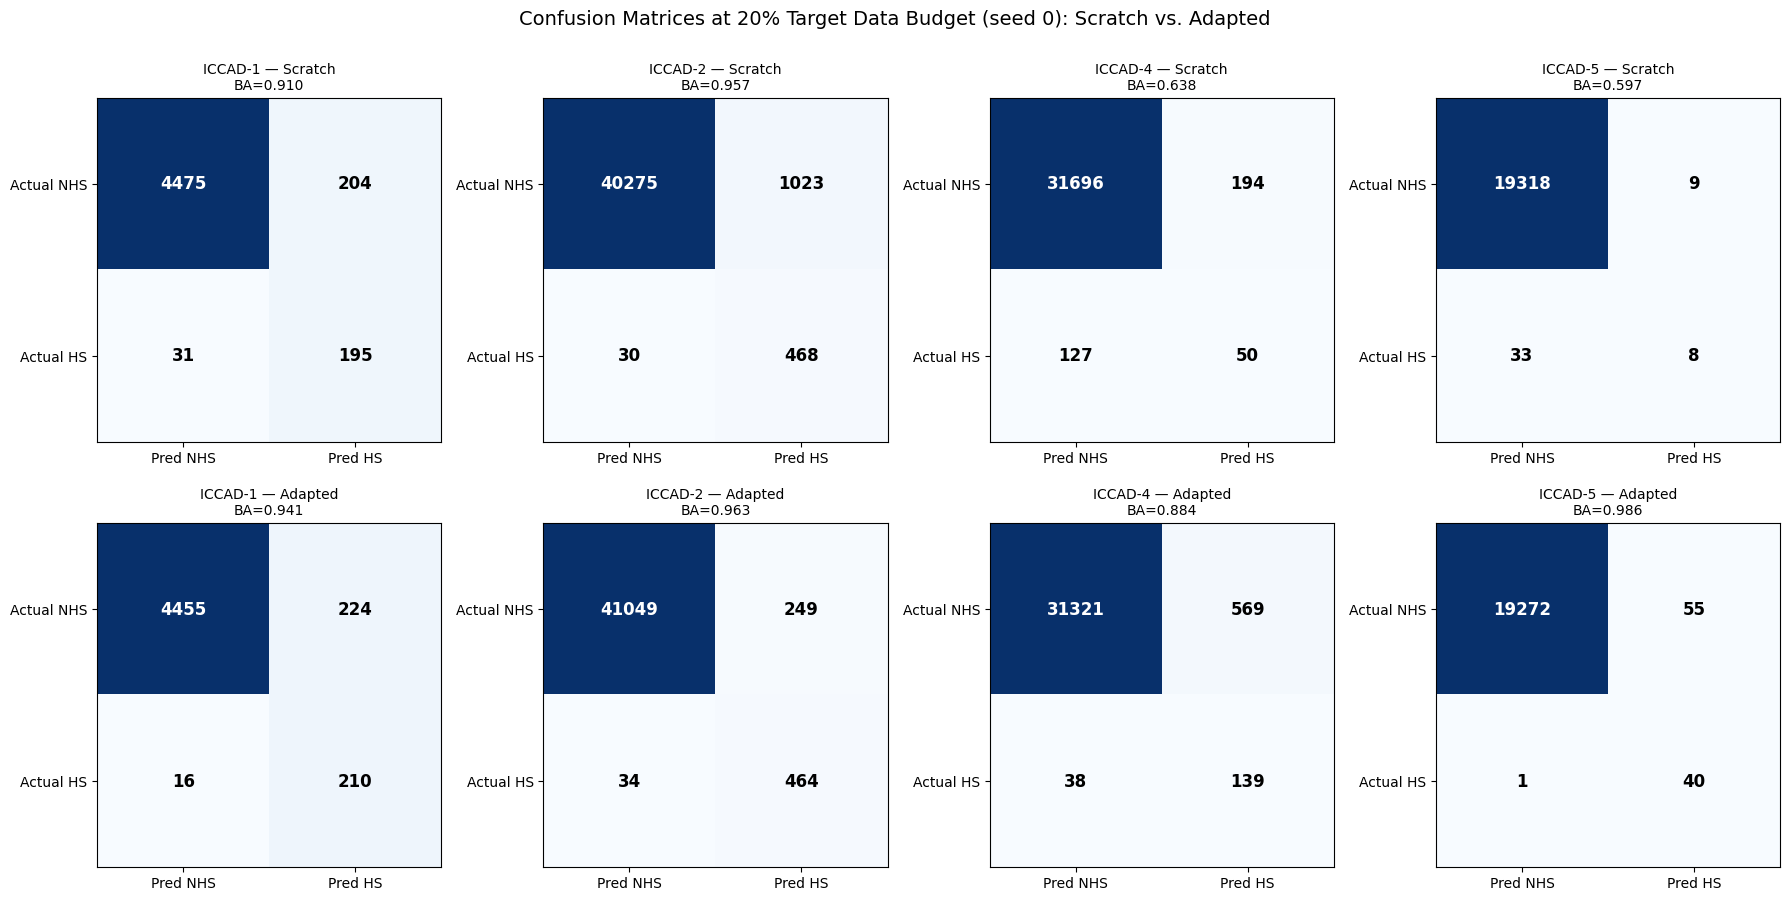

Saved to Drive: confusion_matrices.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_data = {}

for bm in ["iccad1", "iccad2", "iccad4", "iccad5"]:
    X_test, y_test = get_split(bm, "test")
    X_sub, y_sub = budget_data[f"{bm}_20pct_seed0"]

    model_s = build_baseline_cnn()
    model_s.compile(optimizer=keras.optimizers.Nadam(learning_rate=1e-3),
                     loss="binary_crossentropy", metrics=["accuracy"])
    model_s.fit(X_sub, y_sub, epochs=15, batch_size=8, verbose=0)
    y_pred_s = (model_s.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    cm_s = confusion_matrix(y_test, y_pred_s, labels=[0, 1])
    del model_s; keras.backend.clear_session(); gc.collect()

    model_a = build_baseline_cnn()
    model_a.load_weights("/content/drive/MyDrive/source_model_iccad3.weights.h5")
    model_a.compile(optimizer=keras.optimizers.Nadam(learning_rate=1e-4),
                     loss="binary_crossentropy", metrics=["accuracy"])
    model_a.fit(X_sub, y_sub, epochs=15, batch_size=8, verbose=0)
    y_pred_a = (model_a.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    cm_a = confusion_matrix(y_test, y_pred_a, labels=[0, 1])
    del model_a; keras.backend.clear_session(); gc.collect()

    cm_data[bm] = {"scratch": cm_s, "adapted": cm_a}
    print(f"{bm} done")

def balanced_acc_from_cm(cm):
    tn, fp = cm[0]; fn, tp = cm[1]
    sens = tp / (tp + fn) if (tp+fn) > 0 else 0
    spec = tn / (tn + fp) if (tn+fp) > 0 else 0
    return (sens + spec) / 2

benchmarks = ["iccad1", "iccad2", "iccad4", "iccad5"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, bm in enumerate(benchmarks):
    for row, method in enumerate(["scratch", "adapted"]):
        cm = cm_data[bm][method]
        ax = axes[row, col]
        ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                val = cm[i, j]
                ax.text(j, i, str(val), ha="center", va="center",
                        color="white" if val > cm.max()/2 else "black", fontsize=12, fontweight="bold")
        ax.set_xticks([0,1]); ax.set_xticklabels(["Pred NHS", "Pred HS"])
        ax.set_yticks([0,1]); ax.set_yticklabels(["Actual NHS", "Actual HS"])
        ba = balanced_acc_from_cm(cm)
        ax.set_title(f"{bm.upper().replace('ICCAD','ICCAD-')} — {'Scratch' if method=='scratch' else 'Adapted'}\nBA={ba:.3f}", fontsize=10)

plt.suptitle("Confusion Matrices at 20% Target Data Budget (seed 0): Scratch vs. Adapted", fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved to Drive: confusion_matrices.png")